# Hello World Agent

Lesgo!

In [ ]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph  # the framework that helps us design and manage the flow of task

In [12]:
# creating AgentState which is a shared data structure that keeps trank of information as our application runs
class AgentState(TypedDict):  # our state schema
    message: str


def greeting_node(state:AgentState) ->AgentState:
    """
    This function is a node in the state graph that sets the initial greeting message.
    """
    state["message"]="Hey " + state["message"]+", how is your day going?"
    return state

In [13]:
graph= StateGraph(AgentState)  # creating a state graph with our AgentState schema
graph.add_node("greeter" ,greeting_node)  # adding the greeting node to the graph (greeter is the name of the node,and the function is greeting_node)

graph.set_entry_point("greeter")  # setting the entry point of the graph to the "greeter" node
graph.set_finish_point("greeter")  # setting the finish point of the graph to the "greeter" node as well

app=graph.compile()

In [7]:
!pip install Ipython


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


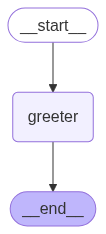

In [10]:
# visualize the graph

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))


In [18]:
result=app.invoke({"message":"Bob"})  # invoking the application with an initial message "Bob"
## or
result=app.invoke(AgentState(message="Bob"))  # invoking the application with an initial message "Bob" using AgentState

In [19]:
result["message"]

'Hey Bob, how is your day going?'

## Personalized Compliment

In [20]:
class AgentState(TypedDict):  # our state schema
    message:str
    job: str

In [21]:
def compliment(state:AgentState)->AgentState:
    """
    This function complements a person based on their job
    """
    state["message"]="Hey " + state["message"] + ", you are doing a great job as a " + state["job"] + "!"
    return state

In [22]:
graph=StateGraph(AgentState)  # creating a new state graph with our updated AgentState schema
graph.add_node("complimenter", compliment)  # adding the compliment node to the graph
graph.set_entry_point("complimenter")  # setting the entry point of the graph to the "complimenter" node
graph.set_finish_point("complimenter")  # setting the finish point of the graph to the "complimenter" node as well

In [23]:
app=graph.compile()


In [24]:
result=app.invoke({"message":"Bob", "job":"developer"})  # invoking the application with an initial message "Bob" and job "developer"
## or
result["message"]

'Hey Bob, you are doing a great job as a developer!'